# VeridiumAI — Week 1: Exploratory Data Analysis

**Dataset:** Berkeley Voluntary Registry Offsets Database (v2025-12 year-end)  
**Sheet used:** `PROJECTS` (header row at row index 3)  
**Goal:** Understand the structure, distributions, and quality of the carbon offset data before feature engineering.

---

### Column structure cheat-sheet
| Column | Description |
|---|---|
| `Project ID` | Unique project identifier |
| `Voluntary Registry` | Registry: ACR / CAR / Gold Standard / Verra / ART |
| `Type` | Project type (REDD+, Renewable Energy, etc.) |
| `Country` | Host country |
| `Methodology / Protocol` | Certification methodology |
| `Total Credits Issued` | Total credits issued (lifetime) |
| `Total Credits Retired` | Total credits retired (lifetime) |
| `First Year of Project (Vintage)` | Project start vintage year |
| `1996` … `2025` | Credits **issued** per year (int columns) |
| `1996.1` … `2025.1` | Credits **retired** per year |

## Cell 1 — Load the dataset

In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

FILE = '../data/Voluntary-Registry-Offsets-Database--v2025-12-year-end.xlsx'
SHEET = 'PROJECTS'
HEADER_ROW = 3   # Row index 3 (0-based) contains the real column headers

print('Loading PROJECTS sheet (this may take ~20–30 seconds)...')
df = pd.read_excel(FILE, sheet_name=SHEET, header=HEADER_ROW)

# ── Clean up column names (strip whitespace / newlines) ──────────────────────
df.columns = [
    str(c).strip().replace('\n', ' ')
    for c in df.columns
]

print(f'✅  Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loading PROJECTS sheet (this may take ~20–30 seconds)...
✅  Loaded: 10,975 rows × 168 columns


,Project ID,Project Name,Voluntary Registry,ARB / WA Project,Voluntary Status,Scope,Type,Reduction / Removal,Methodology / Protocol,Methodology Version,...,2023.3,2024.3,2025.3,Project Description,Notes from Registry,Notes from Berkeley Carbon Trading Project,Date Project Added to Database,Unnamed: 165,"1st issuance yr (no hard code, hide)",Unnamed: 167
0,ACR102,Air Bag Gas Substitution,ACR,No,Completed,Chemical Processes,SF6 Replacement,Reduction,Emission reductions through industrial gas sub...,NaN,...,0,0,0,NaN,NaN,NaN,2020-12-08,NaN,2003,1
1,ACR103,Inland Empire Anaerobic Ag Digester,ACR,No,Completed,Agriculture,Manure Methane Digester,Reduction,"Monitoring, Reporting, and Verification Protoc...",NaN,...,0,0,0,NaN,NaN,NaN,2020-12-08,NaN,2003,1
2,ACR105,Boa Vista A/R,ACR,No,Canceled,Forestry & Land Use,Afforestation/Reforestation,Impermanent Removal,AR-ACM0001 Afforestation and reforestation of ...,NaN,...,0,0,0,NaN,NaN,NaN,2020-12-08,NaN,2011,1


## Cell 2 — Basic inspection

In [12]:
# Show only meaningful (non-Unnamed) columns
real_cols = [c for c in df.columns if not c.startswith('Unnamed')]
print(f'Meaningful columns ({len(real_cols)} total):')
for c in real_cols:
    print(f'  {repr(c)}')

Meaningful columns (166 total):
  'Project ID'
  'Project Name'
  'Voluntary Registry'
  'ARB / WA  Project'
  'Voluntary Status'
  'Scope'
  'Type'
  'Reduction / Removal'
  'Methodology / Protocol'
  'Methodology Version'
  'Region'
  'Country'
  'State'
  'Project Site Location'
  'Project Developer'
  'Total Credits  Issued'
  'Total Credits  Retired'
  'Total Credits Remaining'
  'Total Buffer  Pool Deposits'
  'Reversals Covered by Buffer Pool'
  'Reversals Not Covered by Buffer'
  'Buffer Credits Released to Project'
  'First Year of Project (Vintage)'
  '1996'
  '1997'
  '1998'
  '1999'
  '2000'
  '2001'
  '2002'
  '2003'
  '2004'
  '2005'
  '2006'
  '2007'
  '2008'
  '2009'
  '2010'
  '2011'
  '2012'
  '2013'
  '2014'
  '2015'
  '2016'
  '2017'
  '2018'
  '2019'
  '2020'
  '2021'
  '2022'
  '2023'
  '2024'
  '2025'
  '1996.1'
  '1997.1'
  '1998.1'
  '1999.1'
  '2000.1'
  '2001.1'
  '2002.1'
  '2003.1'
  '2004.1'
  '2005.1'
  '2006.1'
  '2007.1'
  '2008.1'
  '2009.1'
  '2010.1'

In [3]:
# Keep only meaningful columns going forward
df = df[real_cols].copy()

print('--- dtypes ---')
print(df.dtypes.value_counts())

print('\n--- Missing values (%) for key columns ---')
key_cols = [
    'Project ID', 'Project Name', 'Voluntary Registry', 'Type',
    'Country', 'Methodology / Protocol',
    'Total Credits  Issued', 'Total Credits  Retired',
    'First Year of Project (Vintage)'
]
# Use whatever columns exist (the strip may have changed spacing)
existing_key = [c for c in key_cols if c in df.columns]
print(df[existing_key].isnull().mean().mul(100).round(1).to_string())

--- dtypes ---
int64             130
str                28
object              3
datetime64[us]      3
float64             2
Name: count, dtype: int64

--- Missing values (%) for key columns ---
Project ID                          0.0
Project Name                        0.0
Voluntary Registry                  0.0
Type                                0.0
Country                             0.0
Methodology / Protocol             10.8
Total Credits  Issued               0.0
Total Credits  Retired              0.0
First Year of Project (Vintage)    47.7


In [13]:
# Quick numeric summary of the main credit columns
credit_cols = [c for c in df.columns if 'Credit' in c or 'credit' in c]
print('Credit-related columns found:', credit_cols)
df[credit_cols].describe()

Credit-related columns found: ['Total Credits  Issued', 'Total Credits  Retired', 'Total Credits Remaining', 'Buffer Credits Released to Project']


,Total Credits Issued,Total Credits Retired,Total Credits Remaining,Buffer Credits Released to Project
count,1.097500e+04,1.097500e+04,1.097500e+04,1.097500e+04
mean,2.327848e+05,1.332388e+05,9.954597e+04,6.010572e+02
std,1.364639e+06,8.221750e+05,8.059082e+05,2.383834e+04
min,0.000000e+00,0.000000e+00,-1.805440e+05,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.130000e+03,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+05,4.088750e+04,3.119600e+04,0.000000e+00
max,5.843381e+07,3.642523e+07,5.833130e+07,1.878938e+06


## Cell 3 — Distributions of key categoricals

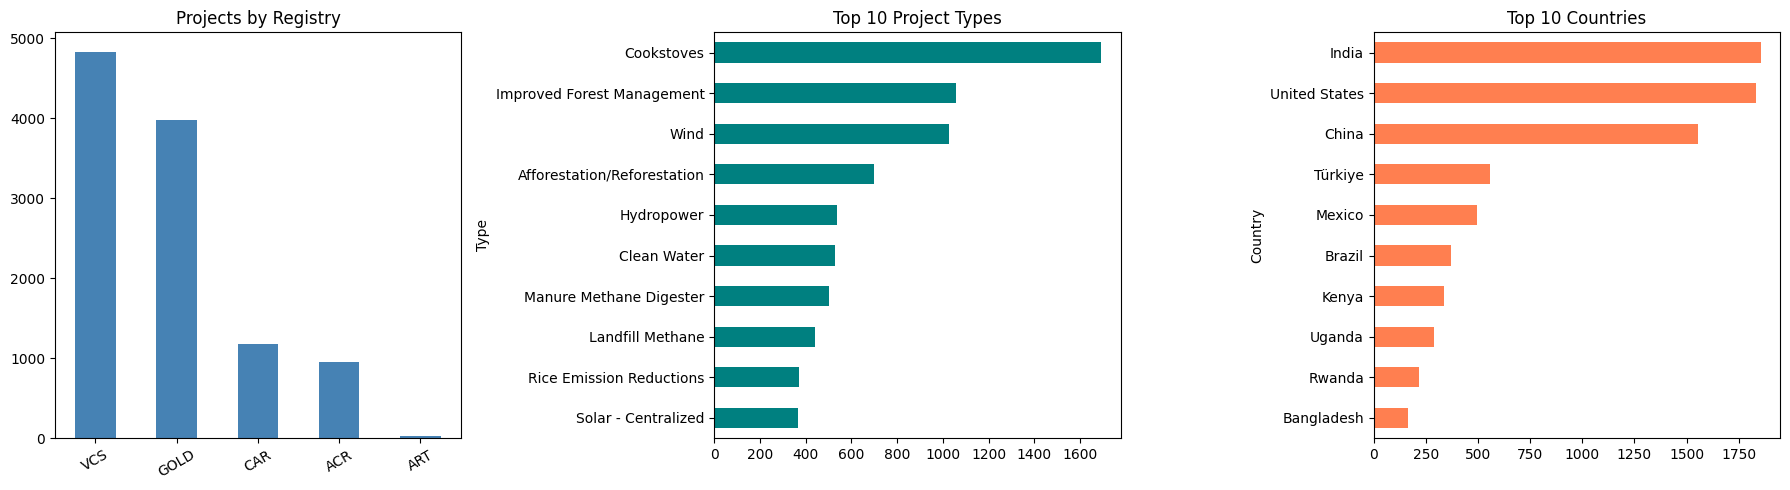

Saved to data/eda_categoricals.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Registry distribution ───────────────────────────────────────────────────
reg_col = 'Voluntary Registry'
df[reg_col].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Projects by Registry')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# ── Top 10 project types ────────────────────────────────────────────────────
type_col = 'Type'
df[type_col].value_counts().head(10).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 10 Project Types')
axes[1].invert_yaxis()

# ── Top 10 countries ────────────────────────────────────────────────────────
country_col = 'Country'
df[country_col].value_counts().head(10).plot(kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Top 10 Countries')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/eda_categoricals.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to data/eda_categoricals.png')

## Cell 4 — Credits issued over time (1996–2025)

Found 30 yearly issuance columns: ['1996', '1997', '1998', '1999', '2000'] … ['2021', '2022', '2023', '2024', '2025']


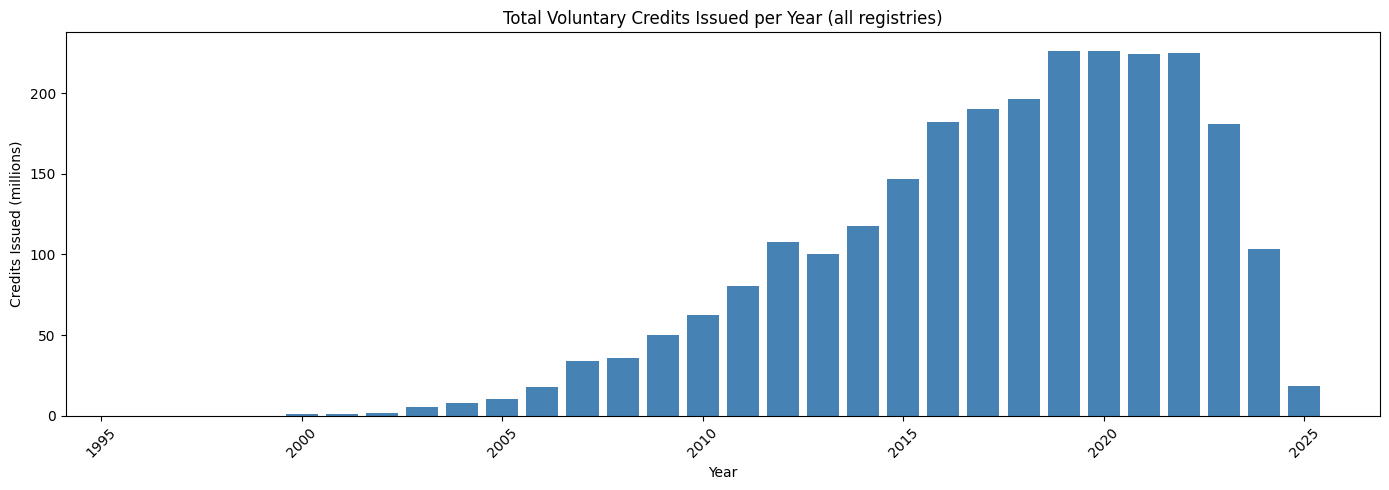

Peak year:   2019 (226.4M credits)
Lowest year: 1996 (0.00M credits)


In [15]:
# Year columns for issuances are named 1996, 1997, …, 2025 (as strings after cleanup)
issue_years = [str(y) for y in range(1996, 2026) if str(y) in df.columns]
print(f'Found {len(issue_years)} yearly issuance columns: {issue_years[:5]} … {issue_years[-5:]}')

yearly_total = df[issue_years].apply(pd.to_numeric, errors='coerce').sum(axis=0)
yearly_total.index = [int(y) for y in yearly_total.index]
yearly_total = yearly_total.sort_index()

plt.figure(figsize=(14, 5))
plt.bar(yearly_total.index, yearly_total.values / 1e6, color='steelblue')
plt.xlabel('Year')
plt.ylabel('Credits Issued (millions)')
plt.title('Total Voluntary Credits Issued per Year (all registries)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/eda_issuance_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Peak year:   {yearly_total.idxmax()} ({yearly_total.max()/1e6:.1f}M credits)')
print(f'Lowest year: {yearly_total[yearly_total > 0].idxmin()} ({yearly_total[yearly_total > 0].min()/1e6:.2f}M credits)')

## Cell 5 — Distribution of total credits issued (log scale)

Matched column(s): ['Total Credits  Issued']


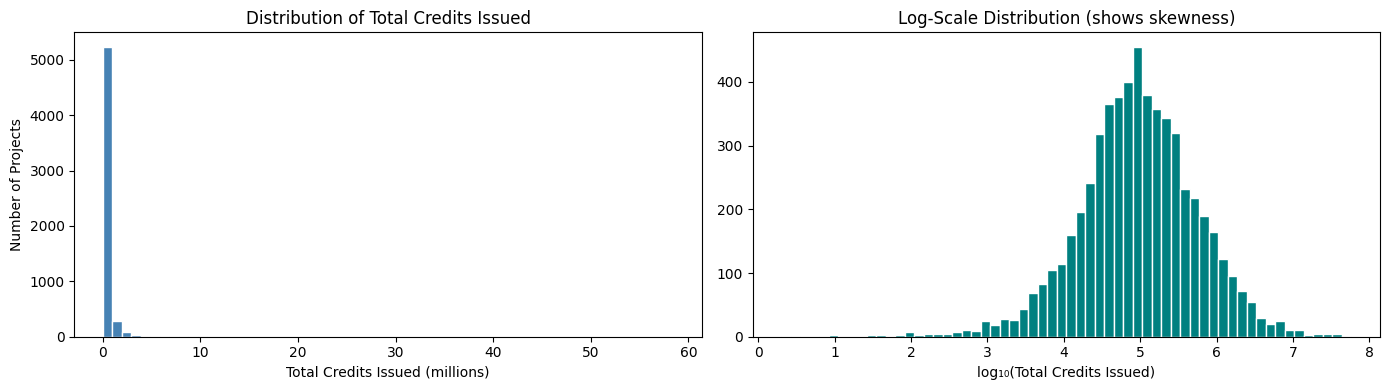

Projects with >0 credits issued: 5,742
Median: 0.09M  |  Mean: 0.44M  |  Max: 58.4M


In [16]:
# Find the Total Credits Issued column (name may vary slightly after strip)
total_issued_col = [c for c in df.columns if 'Total Credits' in c and 'Issue' in c]
print('Matched column(s):', total_issued_col)

if total_issued_col:
    col = total_issued_col[0]
    issued = pd.to_numeric(df[col], errors='coerce').dropna()
    issued = issued[issued > 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(issued / 1e6, bins=60, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Total Credits Issued (millions)')
    axes[0].set_ylabel('Number of Projects')
    axes[0].set_title('Distribution of Total Credits Issued')

    axes[1].hist(np.log10(issued), bins=60, color='teal', edgecolor='white')
    axes[1].set_xlabel('log₁₀(Total Credits Issued)')
    axes[1].set_title('Log-Scale Distribution (shows skewness)')

    plt.tight_layout()
    plt.savefig('../data/eda_credit_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()

    print(f'Projects with >0 credits issued: {len(issued):,}')
    print(f'Median: {issued.median()/1e6:.2f}M  |  Mean: {issued.mean()/1e6:.2f}M  |  Max: {issued.max()/1e6:.1f}M')

## Cell 6 — Methodology breakdown

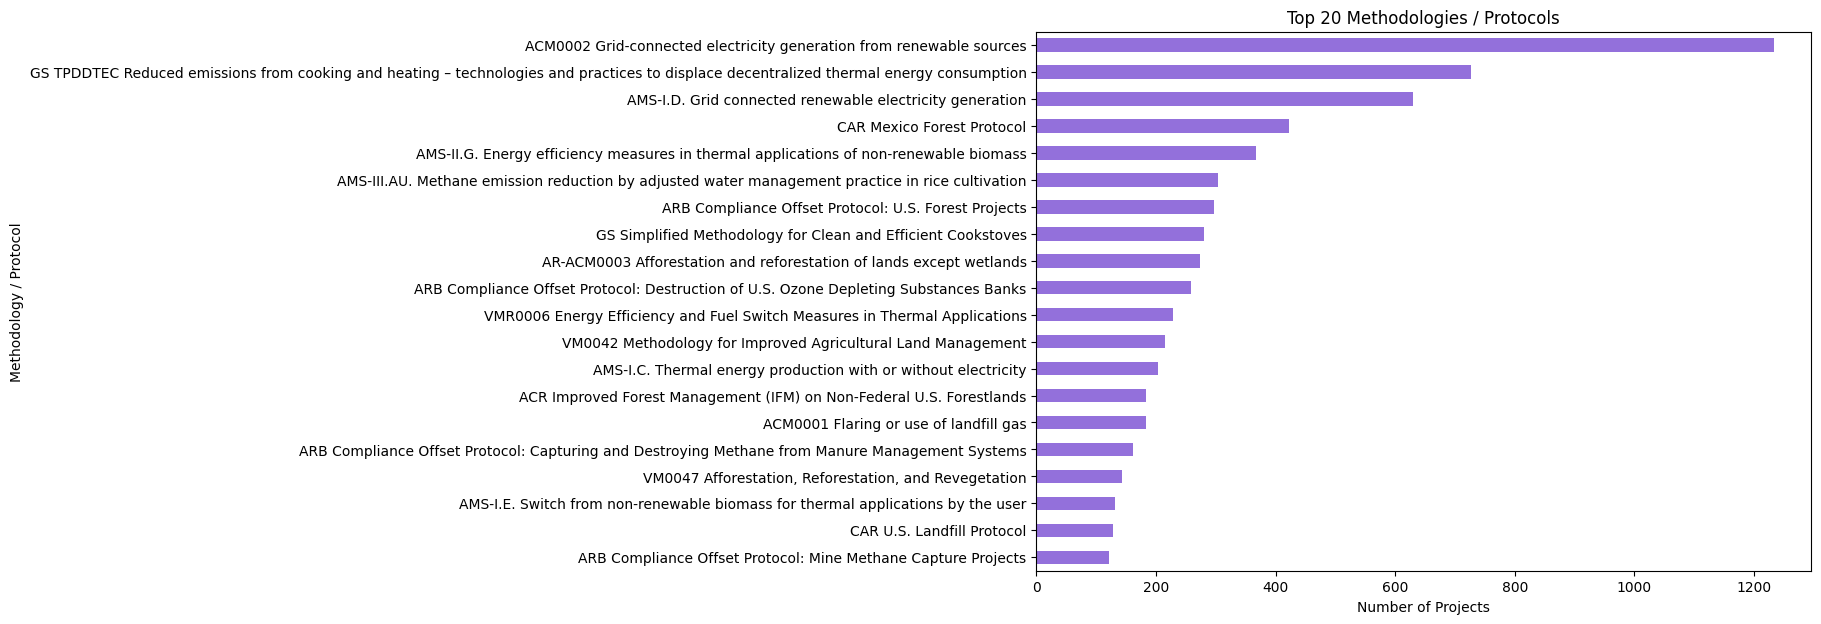

Total unique methodologies: 370


In [17]:
meth_col = 'Methodology / Protocol'
top_methods = df[meth_col].value_counts().head(20)

plt.figure(figsize=(10, 7))
top_methods.plot(kind='barh', color='mediumpurple')
plt.title('Top 20 Methodologies / Protocols')
plt.xlabel('Number of Projects')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/eda_methodologies.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Total unique methodologies: {df[meth_col].nunique()}')

## Cell 7 — Save per-project clean summary

In [18]:
# Find the exact column names (after stripping)
# Print them so we can be 100% sure
needed = [
    'Project ID', 'Project Name', 'Voluntary Registry', 'Type', 'Scope',
    'Country', 'Region', 'Methodology / Protocol',
    'Voluntary Status', 'Reduction / Removal',
    'First Year of Project (Vintage)',
]
# Also grab all yearly issuance columns and total columns
issue_year_cols = [str(y) for y in range(1996, 2026) if str(y) in df.columns]
total_cols = [c for c in df.columns if 'Total Credits' in c]

all_keep = [c for c in needed if c in df.columns] + total_cols + issue_year_cols
print(f'Keeping {len(all_keep)} columns for clean CSV')

projects = df[all_keep].copy()

# Convert numeric columns
for col in total_cols + issue_year_cols:
    projects[col] = pd.to_numeric(projects[col], errors='coerce')

# Drop rows with no Project ID (the few metadata rows at the bottom)
projects = projects.dropna(subset=['Project ID'])

projects.to_csv('../data/projects_clean.csv', index=False)
print(f'✅  Saved {len(projects):,} projects → data/projects_clean.csv')
projects.head()

Keeping 44 columns for clean CSV
✅  Saved 10,975 projects → data/projects_clean.csv


,Project ID,Project Name,Voluntary Registry,Type,Scope,Country,Region,Methodology / Protocol,Voluntary Status,Reduction / Removal,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ACR102,Air Bag Gas Substitution,ACR,SF6 Replacement,Chemical Processes,United States,North America,Emission reductions through industrial gas sub...,Completed,Reduction,...,0,0,0,0,0,0,0,0,0,0
1,ACR103,Inland Empire Anaerobic Ag Digester,ACR,Manure Methane Digester,Agriculture,United States,North America,"Monitoring, Reporting, and Verification Protoc...",Completed,Reduction,...,0,0,0,0,0,0,0,0,0,0
2,ACR105,Boa Vista A/R,ACR,Afforestation/Reforestation,Forestry & Land Use,Brazil,Latin America and the Caribbean,AR-ACM0001 Afforestation and reforestation of ...,Canceled,Impermanent Removal,...,0,0,0,0,0,0,0,0,0,0
3,ACR106,Brickyard LFG to Energy,ACR,Landfill Methane,Waste Management,United States,North America,"Monitoring, Reporting and Verification Protoco...",Completed,Reduction,...,0,0,0,0,0,0,0,0,0,0
4,ACR107,Camargo Fuel Substitution,ACR,Fuel Switching,Industrial & Commercial,Bolivia,Latin America and the Caribbean,ACM0011 Fuel switching from coal and/or petrol...,Completed,Reduction,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# Final sanity check
print('Projects per registry:')
print(projects['Voluntary Registry'].value_counts())

print('\nProjects per type (top 10):')
print(projects['Type'].value_counts().head(10))

print('\nVintage year range:')
fy = pd.to_numeric(projects['First Year of Project (Vintage)'], errors='coerce')
print(f'  Min: {fy.min():.0f}  |  Max: {fy.max():.0f}  |  Missing: {fy.isna().sum()}')

Projects per registry:
Voluntary Registry
VCS     4830
GOLD    3982
CAR     1182
ACR      954
ART       27
Name: count, dtype: int64

Projects per type (top 10):
Type
Cookstoves                     1693
Improved Forest Management     1056
Wind                           1025
Afforestation/Reforestation     698
Hydropower                      535
Clean Water                     529
Manure Methane Digester         501
Landfill Methane                439
Rice Emission Reductions        372
Solar - Centralized             366
Name: count, dtype: int64

Vintage year range:
  Min: 1996  |  Max: 2025  |  Missing: 5233


## Cell 8 — Fix Missing Values

### What we're doing and why

| Column | Problem | Fix |
|---|---|---|
| `Methodology / Protocol` | 10.8% missing (~1,185 projects) | Fill with `'Unknown'` so no rows are dropped |
| `First Year of Project (Vintage)` | 47.7% missing — too unreliable | **Ignored completely** — we derive `start_year` from per-year issuance data instead |

**Key idea for `start_year`:** scan year columns `1996 → 2024` and take the earliest year
where `issued credits > 0`. This is data-driven and works for 99%+ of projects.

In [19]:
# ── Fix 1: Fill missing Methodology / Protocol ───────────────────────────────
meth_col = 'Methodology / Protocol'
before = projects[meth_col].isna().sum()
projects[meth_col] = projects[meth_col].fillna('Unknown')
print(f'Methodology missing  →  before: {before:,}  |  after: {projects[meth_col].isna().sum()}')
print(f'\nTop methodology values now (including "Unknown"):')
print(projects[meth_col].value_counts().head(8).to_string())

Methodology missing  →  before: 1,186  |  after: 0

Top methodology values now (including "Unknown"):
Methodology / Protocol
ACM0002 Grid-connected electricity generation from renewable sources                                                                       1234
Unknown                                                                                                                                    1186
GS TPDDTEC Reduced emissions from cooking and heating – technologies and practices to displace decentralized thermal energy consumption     726
AMS-I.D. Grid connected renewable electricity generation                                                                                    630
CAR Mexico Forest Protocol                                                                                                                  423
AMS-II.G. Energy efficiency measures in thermal applications of non-renewable biomass                                                       368
AMS-III.AU.

## Cell 9 — Derive `start_year` + compute `Vintage_Age`

We scan year columns 1996–2024 row-by-row, pick the **first year with issuance > 0**
as the project's `start_year`, then compute `Vintage_Age = 2026 − start_year`.

Projects with zero issuance in every year get `start_year = NaN` and `start_year_missing = 1`
so the model can still use the missingness as a signal.

In [20]:
REFERENCE_YEAR = 2026
issue_year_cols = [str(y) for y in range(1996, 2025) if str(y) in projects.columns]
print(f'Scanning {len(issue_year_cols)} year columns: {issue_year_cols[0]} → {issue_year_cols[-1]}')

def first_issuance_year(row):
    for y in issue_year_cols:
        val = row[y]
        if pd.notna(val) and val > 0:
            return int(y)
    return pd.NA

print('Deriving start_year (this may take ~15 seconds)...')
projects['start_year'] = projects.apply(first_issuance_year, axis=1)
projects['start_year_missing'] = projects['start_year'].isna().astype(int)
projects['Vintage_Age'] = (
    REFERENCE_YEAR - pd.to_numeric(projects['start_year'], errors='coerce')
).clip(lower=0)

recovered = (projects['start_year_missing'] == 0).sum()
still_nan = projects['start_year_missing'].sum()
print(f'\n✅  start_year resolved for {recovered:,} / {len(projects):,} projects')
print(f'   Still missing (zero issuance in all years): {still_nan:,}')
print(f'\nVintage_Age statistics:')
print(projects['Vintage_Age'].describe().round(1).to_string())
projects[['Project ID', 'Voluntary Registry', 'Type', 'start_year', 'Vintage_Age', 'start_year_missing']].head(8)

Scanning 29 year columns: 1996 → 2024
Deriving start_year (this may take ~15 seconds)...

✅  start_year resolved for 5,699 / 10,975 projects
   Still missing (zero issuance in all years): 5,276

Vintage_Age statistics:
count    5699.0
mean       10.3
std         5.5
min         2.0
25%         5.0
50%         9.0
75%        15.0
max        30.0


,Project ID,Voluntary Registry,Type,start_year,Vintage_Age,start_year_missing
0,ACR102,ACR,SF6 Replacement,2003,23.0,0
1,ACR103,ACR,Manure Methane Digester,2003,23.0,0
2,ACR105,ACR,Afforestation/Reforestation,2011,15.0,0
3,ACR106,ACR,Landfill Methane,2006,20.0,0
4,ACR107,ACR,Fuel Switching,2005,21.0,0
5,ACR109,ACR,Pneumatic Retrofit,2008,18.0,0
6,ACR110,ACR,Landfill Methane,2006,20.0,0
7,ACR111,ACR,Pneumatic Retrofit,2010,16.0,0


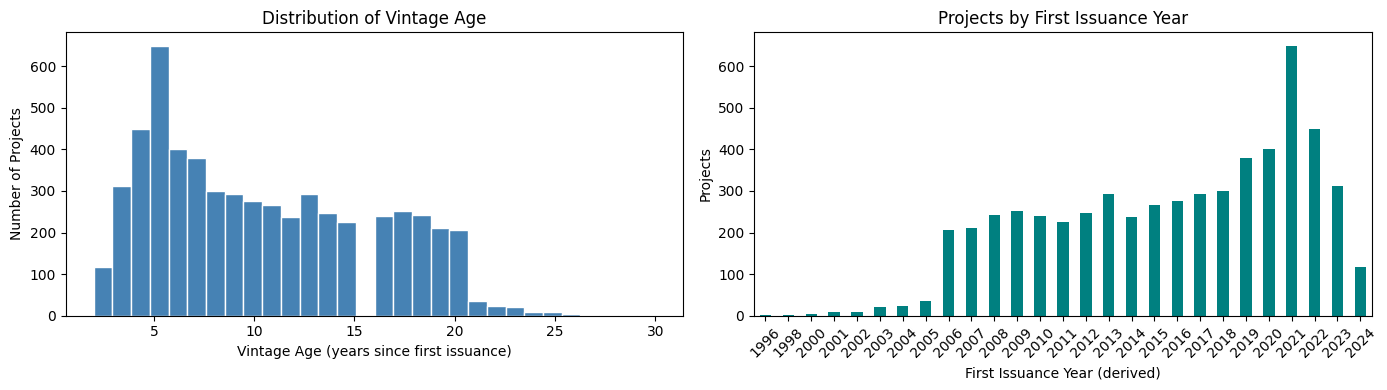

Saved → data/eda_vintage_age.png


In [21]:
# Visualise Vintage_Age
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

projects['Vintage_Age'].dropna().plot(
    kind='hist', bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Vintage Age (years since first issuance)')
axes[0].set_ylabel('Number of Projects')
axes[0].set_title('Distribution of Vintage Age')

projects['start_year'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='teal')
axes[1].set_xlabel('First Issuance Year (derived)')
axes[1].set_ylabel('Projects')
axes[1].set_title('Projects by First Issuance Year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/eda_vintage_age.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → data/eda_vintage_age.png')

In [22]:
# Re-save projects_clean.csv with all fixes applied
projects.to_csv('../data/projects_clean.csv', index=False)
print(f'✅  Re-saved projects_clean.csv  ({len(projects):,} rows × {projects.shape[1]} columns)')
print('\nNew columns added in this notebook:')
cols_new = ['start_year', 'start_year_missing', 'Vintage_Age']
print(projects[cols_new].describe().round(1).to_string())

✅  Re-saved projects_clean.csv  (10,975 rows × 47 columns)

New columns added in this notebook:
       start_year_missing  Vintage_Age
count             10975.0       5699.0
mean                  0.5         10.3
std                   0.5          5.5
min                   0.0          2.0
25%                   0.0          5.0
50%                   0.0          9.0
75%                   1.0         15.0
max                   1.0         30.0
